# Analyse Exploratoire

### Import des modules

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  

### Analyse Exploratoire

In [182]:
df = pd.read_csv('2016_Building_Energy_Benchmarking.csv')

In [183]:
# On regarde comment un batiment est défini dans ce jeu de données 
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [184]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [185]:
df.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,...,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,...,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,...,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,...,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,...,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,...,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,...,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,...,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,...,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


In [186]:
df.shape

(3376, 46)

In [187]:
missing_summary = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["colonne", "pourcentage_valeurs_manquantes"]

missing_summary

,colonne,pourcentage_valeurs_manquantes
0,Comments,100.000000
1,Outlier,99.052133
2,YearsENERGYSTARCertified,96.475118
3,ThirdLargestPropertyUseType,82.345972
4,ThirdLargestPropertyUseTypeGFA,82.345972
5,SecondLargestPropertyUseType,50.266588
6,SecondLargestPropertyUseTypeGFA,50.266588
7,ENERGYSTARScore,24.970379
8,LargestPropertyUseTypeGFA,0.592417
9,LargestPropertyUseType,0.592417


#### TERMINER L'ANALYSE EXPLORATOIRE 

In [188]:
colonnes_majorite_manquantes = missing_summary[
    missing_summary["pourcentage_valeurs_manquantes"] > 50
]

colonnes_majorite_manquantes

,colonne,pourcentage_valeurs_manquantes
0,Comments,100.000000
1,Outlier,99.052133
2,YearsENERGYSTARCertified,96.475118
3,ThirdLargestPropertyUseType,82.345972
4,ThirdLargestPropertyUseTypeGFA,82.345972
5,SecondLargestPropertyUseType,50.266588
6,SecondLargestPropertyUseTypeGFA,50.266588


In [189]:
cols_to_check = [
    "Comments",
    "Outlier",
    "YearsENERGYSTARCertified",
    "ThirdLargestPropertyUseType",
    "ThirdLargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA"
]

for col in cols_to_check:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))


--- Comments ---
Comments
NaN    3376
Name: count, dtype: int64

--- Outlier ---
Outlier
NaN             3344
Low outlier       23
High outlier       9
Name: count, dtype: int64

--- YearsENERGYSTARCertified ---
YearsENERGYSTARCertified
NaN         3257
2016          14
20172016       8
2017           7
2014           6
20162015       6
2009           4
2013           4
20172015       3
20152014       3
Name: count, dtype: int64

--- ThirdLargestPropertyUseType ---
ThirdLargestPropertyUseType
NaN                           2780
Retail Store                   110
Office                         105
Parking                         71
Restaurant                      56
Other                           49
Swimming Pool                   29
Non-Refrigerated Warehouse      18
Medical Office                  17
Data Center                     14
Name: count, dtype: int64

--- ThirdLargestPropertyUseTypeGFA ---
ThirdLargestPropertyUseTypeGFA
NaN       2780
0.0         48
6000.0       7
5000.0   

In [190]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(5))


--- OSEBuildingID ---
OSEBuildingID
1    1
2    1
3    1
5    1
8    1
Name: count, dtype: int64

--- DataYear ---
DataYear
2016    3376
Name: count, dtype: int64

--- BuildingType ---
BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Name: count, dtype: int64

--- PrimaryPropertyType ---
PrimaryPropertyType
Low-Rise Multifamily           987
Mid-Rise Multifamily           564
Small- and Mid-Sized Office    293
Other                          256
Warehouse                      187
Name: count, dtype: int64

--- PropertyName ---
PropertyName
Northgate Plaza            3
Lakeview                   2
South Park                 2
Garden Court Apartments    2
Central Park               2
Name: count, dtype: int64

--- Address ---
Address
2600 SW Barton St              4
2203 Airport Way S             4
309 South Cloverdale Street    4
500 5TH AVE                    2
3613 4th Ave S   

In [191]:
constant_summary = []

for col in df.columns:
    vc = df[col].value_counts(dropna=False, normalize=True)
    top_value = vc.index[0]
    top_freq = vc.iloc[0] * 100
    nb_unique = df[col].nunique(dropna=False)
    
    constant_summary.append({
        "colonne": col,
        "valeur_majoritaire": top_value,
        "frequence_%": top_freq,
        "nb_valeurs_uniques": nb_unique
    })

constant_summary = pd.DataFrame(constant_summary)
constant_summary.sort_values("frequence_%", ascending=False).head(20)

,colonne,valeur_majoritaire,frequence_%,nb_valeurs_uniques
1,DataYear,2016,100.000000,1
6,City,Seattle,100.000000,1
7,State,WA,100.000000,1
41,Comments,NaN,100.000000,1
43,Outlier,NaN,99.052133,3
40,DefaultData,False,96.652844,2
27,YearsENERGYSTARCertified,NaN,96.475118,66
35,SteamUse(kBtu),0.0,95.882701,132
42,ComplianceStatus,Compliant,95.112559,4
15,NumberofBuildings,1.0,94.046209,18


In [192]:
df["ListOfAllPropertyUseTypes"].value_counts(dropna=False).head(20)

ListOfAllPropertyUseTypes
Multifamily Housing                           866
Multifamily Housing, Parking                  464
Office                                        139
K-12 School                                   135
Office, Parking                               120
Non-Refrigerated Warehouse                    101
Other                                          61
Non-Refrigerated Warehouse, Office             61
Retail Store                                   56
Multifamily Housing, Retail Store              52
Multifamily Housing, Parking, Retail Store     51
Worship Facility                               48
Hotel                                          44
Office, Retail Store                           43
Multifamily Housing, Office, Parking           40
Multifamily Housing, Office                    26
Distribution Center                            24
Self-Storage Facility                          23
College/University                             21
Senior Care Community   

In [193]:
df["is_multi_usage"] = df["ListOfAllPropertyUseTypes"].astype(str).str.contains(",")

df["usage_type"] = np.where(
    df["is_multi_usage"],
    "Multi-usage",
    "Mono-usage"
)

df["usage_type"].value_counts()

usage_type
Mono-usage     1700
Multi-usage    1676
Name: count, dtype: int64

In [194]:
df.groupby("usage_type")[
    [
        "PropertyGFATotal",
        "SiteEUI(kBtu/sf)",
        "SourceEUI(kBtu/sf)",
        "SiteEnergyUse(kBtu)",
        "TotalGHGEmissions",
        "GHGEmissionsIntensity",
        "ENERGYSTARScore",
        "Electricity(kWh)"
    ]
].describe()

PropertyGFATotal                                                   \
                       count           mean            std      min       25%   
usage_type                                                                      
Mono-usage            1700.0   68432.381765  238161.785738  11285.0  26084.75   
Multi-usage           1676.0  121612.752387  193741.675597  12769.0  31756.00   

                                           SiteEUI(kBtu/sf)             ...  \
                 50%        75%        max            count       mean  ...   
usage_type                                                              ...   
Mono-usage   38445.0   63740.25  9320156.0           1694.0  49.265703  ...   
Multi-usage  55897.0  126883.50  2200000.0           1675.0  60.260537  ...   

            ENERGYSTARScore        Electricity(kWh)                \
                        75%    max            count          mean   
usage_type                                                          
Mono-usage             88.0  100.0           1691.0  7.614078e+05   
Multi-usage            92.0  100.0           1676.0  1.414781e+06   

                                                                    \
                      std          min           25%           50%   
usage_type                                                           
Mono-usage   4.932345e+06 -33826.80078  158623.50005  267431.00000   
Multi-usage  3.648107e+06      0.00000  232456.82810  462490.90625   

                                        
                      75%          max  
usage_type                              
Mono-usage   5.433111e+05  192577488.0  
Multi-usage  1.190360e+06   80460872.0  

[2 rows x 64 columns]

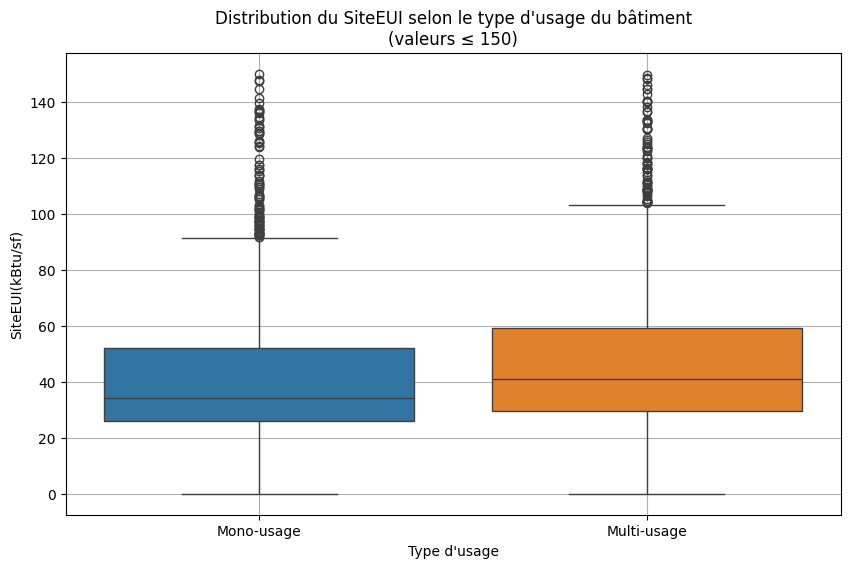

In [195]:
# Seuil d'affichage
seuil = 150

# Filtrage uniquement pour le graphique
df_boxplot = df[df["SiteEUI(kBtu/sf)"] <= seuil].copy()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_boxplot,
    x="usage_type",
    y="SiteEUI(kBtu/sf)",
    hue="usage_type",
    legend=False
)

plt.title(f"Distribution du SiteEUI selon le type d'usage du bâtiment\n(valeurs ≤ {seuil})")
plt.xlabel("Type d'usage")
plt.ylabel("SiteEUI(kBtu/sf)")
plt.grid(True)

plt.show()

In [196]:
comparison_usage = df.groupby("usage_type").agg({
    "PropertyGFATotal": "median",
    "SiteEUI(kBtu/sf)": "median",
    "SourceEUI(kBtu/sf)": "median",
    "SiteEnergyUse(kBtu)": "median",
    "TotalGHGEmissions": "median",
    "GHGEmissionsIntensity": "median",
    "ENERGYSTARScore": "median",
    "Electricity(kWh)": "median"
})

comparison_usage

,PropertyGFATotal,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,ENERGYSTARScore,Electricity(kWh)
usage_type,,,,,,,,
Mono-usage,38445.0,34.799999,88.099998,1408291.375,26.540,0.64,72.0,267431.00000
Multi-usage,55897.0,42.400002,106.549999,2338402.875,42.965,0.60,79.0,462490.90625


In [197]:
cols_pairplot = [
    "PropertyGFATotal",
    "NumberofFloors",
    "SiteEUI(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions",
    "GHGEmissionsIntensity",
    "Electricity(kWh)"
]

df_pairplot = df[cols_pairplot + ["usage_type"]].dropna()

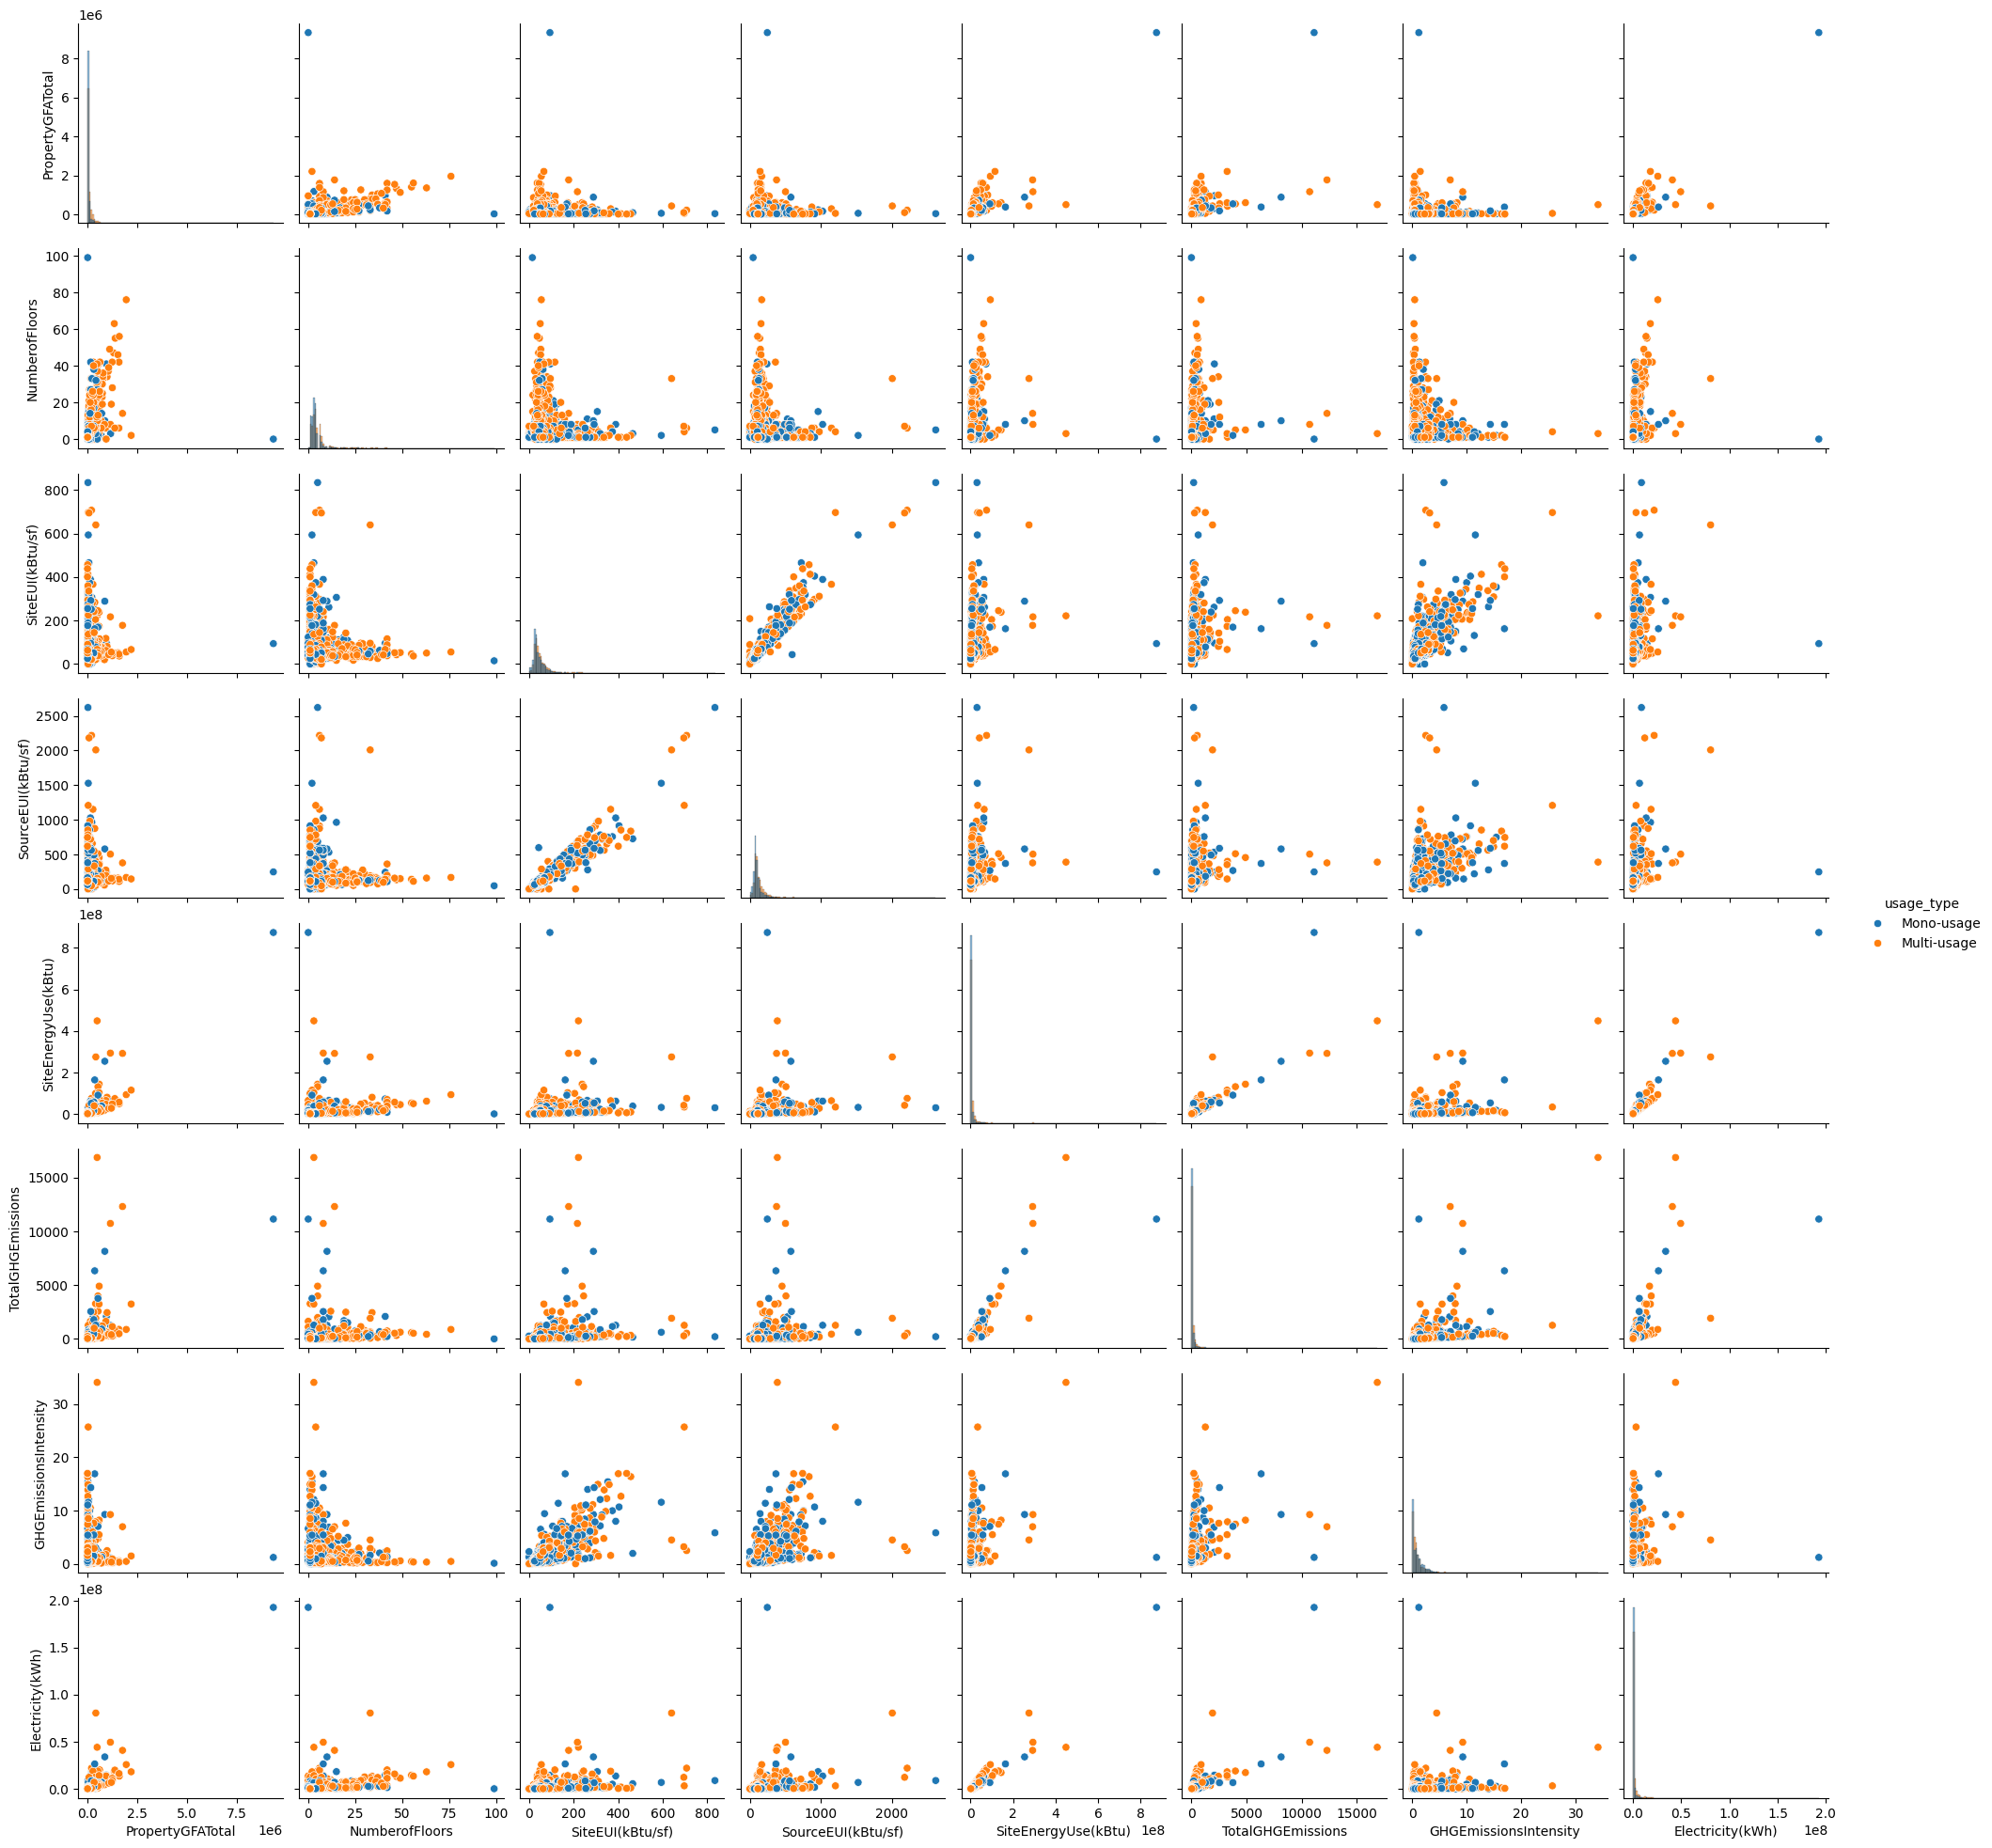

In [198]:
sns.pairplot(
    df_pairplot,
    hue="usage_type",
    diag_kind="hist"
)

plt.show()

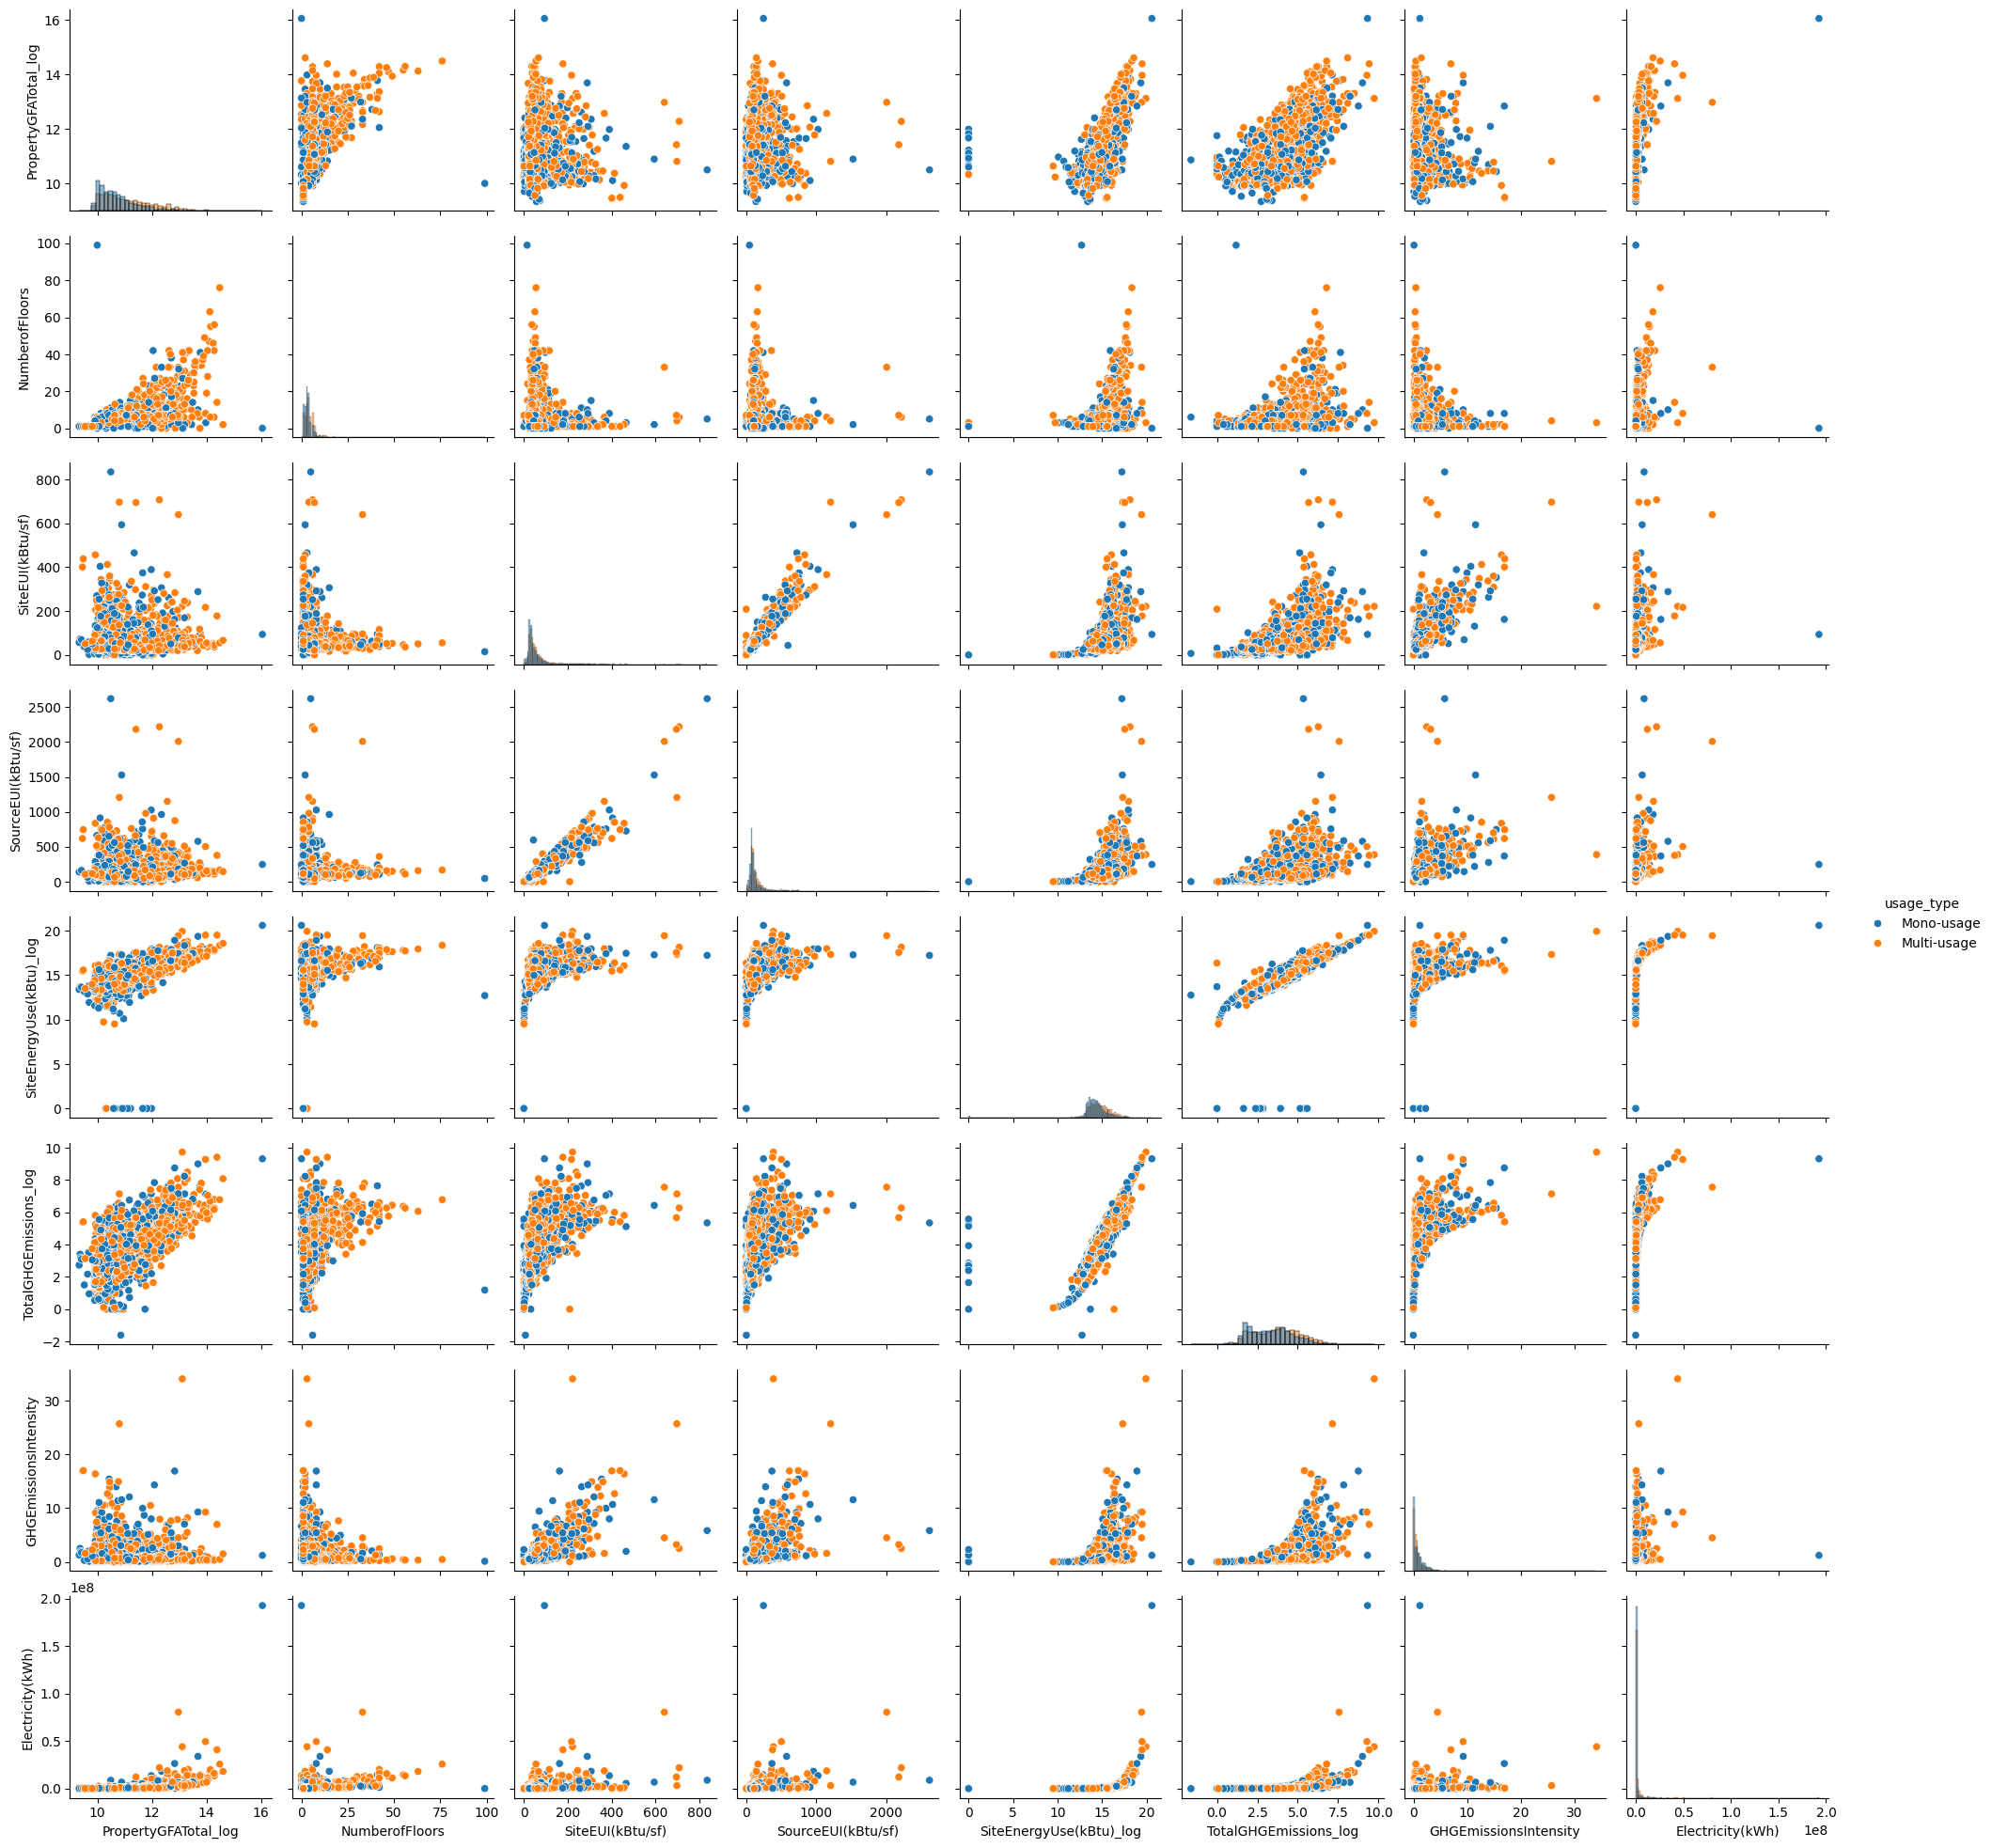

In [199]:
df_log = df_pairplot.copy()

cols_log = [
    "PropertyGFATotal",
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions"
]

for col in cols_log:
    df_log[col + "_log"] = np.log1p(df_log[col])

cols_pairplot_log = [
    "PropertyGFATotal_log",
    "NumberofFloors",
    "SiteEUI(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "SiteEnergyUse(kBtu)_log",
    "TotalGHGEmissions_log",
    "GHGEmissionsIntensity",
    "Electricity(kWh)"
]

sns.pairplot(
    df_log[cols_pairplot_log + ["usage_type"]],
    hue="usage_type",
    diag_kind="hist"
)

plt.show()

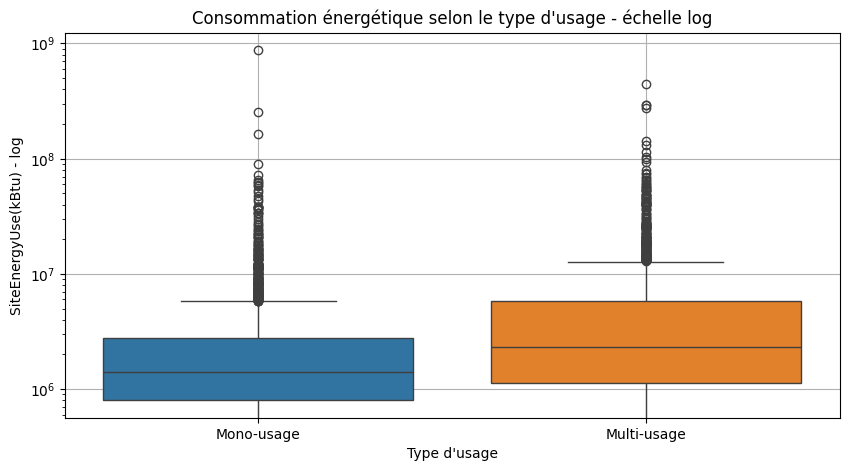

In [200]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="usage_type",
    y="SiteEnergyUse(kBtu)",
    hue="usage_type",
    legend=False
)

plt.yscale("log")
plt.title("Consommation énergétique selon le type d'usage - échelle log")
plt.xlabel("Type d'usage")
plt.ylabel("SiteEnergyUse(kBtu) - log")
plt.grid(True)
plt.show()

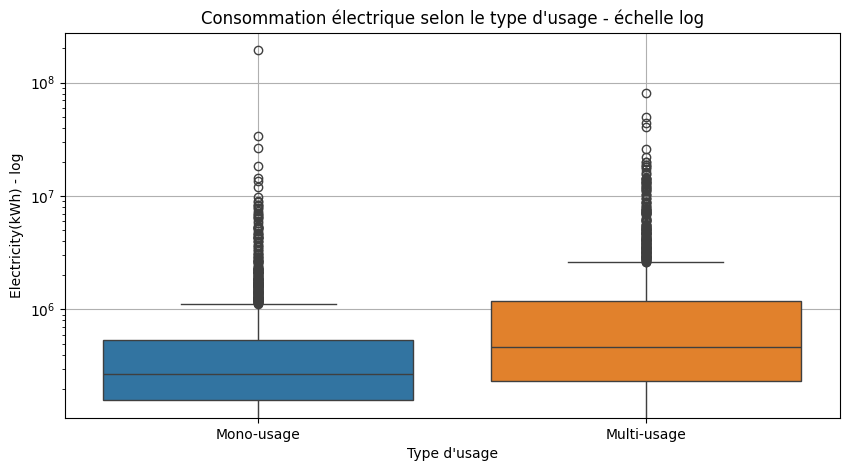

In [201]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="usage_type",
    y="Electricity(kWh)",
    hue="usage_type",
    legend=False
)

plt.yscale("log")
plt.title("Consommation électrique selon le type d'usage - échelle log")
plt.xlabel("Type d'usage")
plt.ylabel("Electricity(kWh) - log")
plt.grid(True)
plt.show()

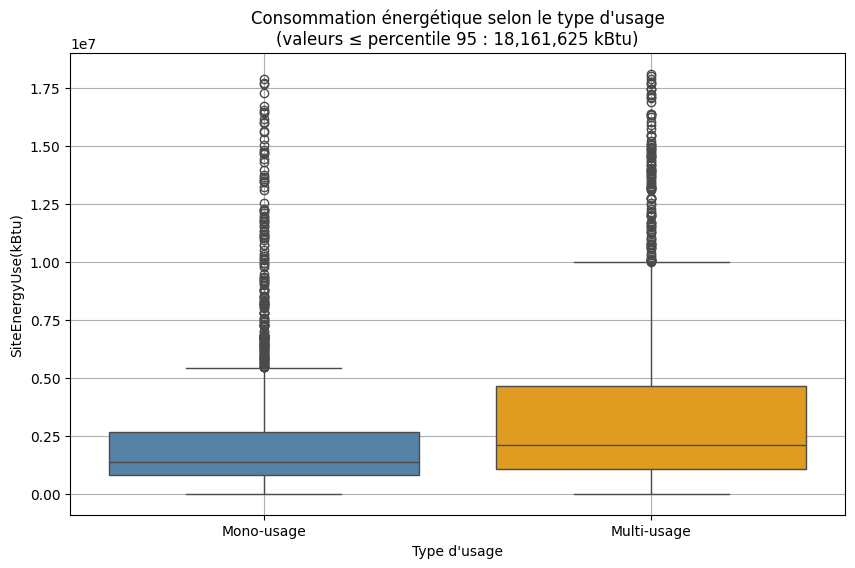

In [202]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target
target = "SiteEnergyUse(kBtu)"

# Seuil d'affichage : percentile 95
seuil = df[target].quantile(0.95)

df_boxplot = df[
    (df["usage_type"] != "Usage inconnu") &
    (df[target] <= seuil)
].copy()

# Palette personnalisée
palette_usage = {
    "Mono-usage": "steelblue",
    "Multi-usage": "orange"
}

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_boxplot,
    x="usage_type",
    y=target,
    hue="usage_type",
    palette=palette_usage,
    legend=False
)

plt.title(f"Consommation énergétique selon le type d'usage\n(valeurs ≤ percentile 95 : {seuil:,.0f} kBtu)")
plt.xlabel("Type d'usage")
plt.ylabel("SiteEnergyUse(kBtu)")
plt.grid(True)

plt.show()

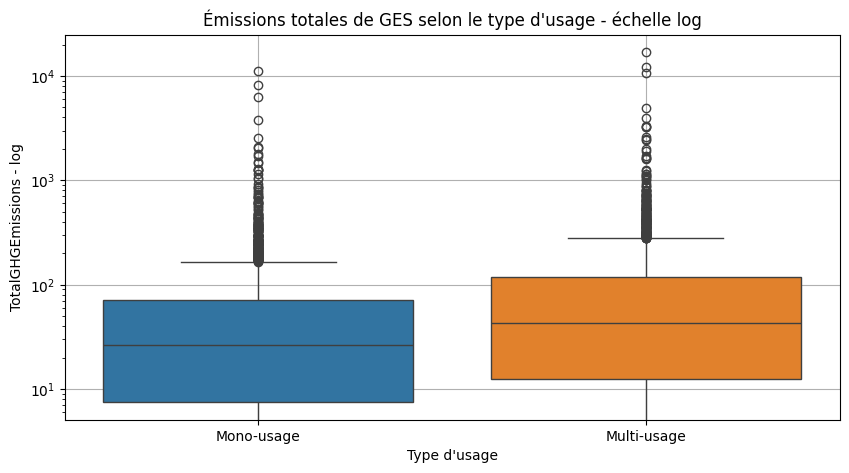

In [203]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="usage_type",
    y="TotalGHGEmissions",
    hue="usage_type",
    legend=False
)

plt.yscale("log")
plt.title("Émissions totales de GES selon le type d'usage - échelle log")
plt.xlabel("Type d'usage")
plt.ylabel("TotalGHGEmissions - log")
plt.grid(True)
plt.show()

L’analyse des valeurs manquantes montre que certaines colonnes sont peu exploitables, notamment Comments, Outlier, YearsENERGYSTARCertified et les colonnes liées au troisième usage du bâtiment. La méthode value_counts(dropna=False) permet également d’identifier des variables constantes ou quasi constantes comme DataYear, City et State, qui apportent peu d’information discriminante dans ce jeu de données.

La création d’une variable distinguant les bâtiments mono-usages et multi-usages permet de comparer leurs profils énergétiques. Les bâtiments multi-usages peuvent présenter des surfaces plus importantes et une consommation énergétique totale plus élevée, mais l’intensité énergétique doit être analysée séparément car elle rapporte la consommation à la surface.

Les pairplots et boxplots mettent en évidence plusieurs valeurs extrêmes, notamment sur SiteEnergyUse(kBtu), TotalGHGEmissions, GHGEmissionsIntensity et SiteEUI(kBtu/sf). Ces observations doivent être vérifiées d’un point de vue métier avant d’être supprimées, car certains outliers peuvent correspondre à de grands bâtiments ou à des usages très énergivores plutôt qu’à des erreurs de données.

# Modélisation 

### Import des modules 

In [204]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

In [205]:
# CODE FEATURE ENGINEERING
def calculer_age_batiment(year):
    if pd.isna(year):
        return np.nan
    return 2016 - year

df["BuildingAge"] = df["YearBuilt"].apply(calculer_age_batiment)

def categoriser_anciennete(year):
    if pd.isna(year):
        return "Inconnu"
    elif year < 1950:
        return "Ancien"
    elif year < 1980:
        return "Intermediaire"
    elif year < 2000:
        return "Recent"
    else:
        return "Tres recent"

df["BuildingAgeCategory"] = df["YearBuilt"].apply(categoriser_anciennete)

def detecter_usage(usages):
    if pd.isna(usages):
        return "Usage inconnu"
    elif "," in usages:
        return "Multi-usage"
    else:
        return "Mono-usage"

df["usage_type"] = df["ListOfAllPropertyUseTypes"].apply(detecter_usage)

def compter_usages(usages):
    if pd.isna(usages):
        return 0
    return len(usages.split(","))

df["NumberOfUseTypes"] = df["ListOfAllPropertyUseTypes"].apply(compter_usages)

def calculer_part_surface_batie(row):
    surface_batie = row["PropertyGFABuilding(s)"]
    surface_totale = row["PropertyGFATotal"]
    
    if pd.isna(surface_batie) or pd.isna(surface_totale) or surface_totale == 0:
        return np.nan
    
    return surface_batie / surface_totale

df["BuildingGFARatio"] = df.apply(calculer_part_surface_batie, axis=1)

def calculer_part_parking(row):
    parking = row["PropertyGFAParking"]
    surface_totale = row["PropertyGFATotal"]
    
    if pd.isna(parking) or pd.isna(surface_totale) or surface_totale == 0:
        return np.nan
    
    return parking / surface_totale

df["ParkingGFARatio"] = df.apply(calculer_part_parking, axis=1)


A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [206]:
# CODE PREPARATION DES FEATURES

colonnes_a_supprimer = [
    # Identifiants ou informations textuelles peu généralisables
    "OSEBuildingID",
    "PropertyName",
    "Address",
    "TaxParcelIdentificationNumber",

    # Variables géographiques 
    "ZipCode",
    "CouncilDistrictCode",
    "Latitude",
    "Longitude",
    "Neighborhood",
   
    
    # Colonnes constantes ou quasi constantes
    "DataYear",
    "City",
    "State",
    
    # Colonnes peu exploitables ou très incomplètes
    "Comments",
    "Outlier",
    "YearsENERGYSTARCertified",
    
    # Colonnes liées à la consommation énergétique : fuite de données
    "SiteEnergyUseWN(kBtu)",
    "SiteEUI(kBtu/sf)",
    "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "SourceEUIWN(kBtu/sf)",
    
    # Détail des sources d'énergie : composantes directes de la target
    "SteamUse(kBtu)",
    "Electricity(kWh)",
    "Electricity(kBtu)",
    "NaturalGas(therms)",
    "NaturalGas(kBtu)",
    
    # Émissions calculées à partir de la consommation
    "TotalGHGEmissions",
    "GHGEmissionsIntensity",
    
    # Score énergétique potentiellement calculé à partir de la performance énergétique
    "ENERGYSTARScore",
    
    # Statuts administratifs
    "DefaultData",
    "ComplianceStatus"
]

In [207]:
colonnes_a_supprimer = [
    col for col in colonnes_a_supprimer 
    if col in df.columns
]

df_model = df.drop(columns=colonnes_a_supprimer)

print("Dimensions après suppression des colonnes peu pertinentes :", df_model.shape)
df_model.head()

Dimensions après suppression des colonnes peu pertinentes : (3376, 23)


,BuildingType,PrimaryPropertyType,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,...,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),is_multi_usage,usage_type,BuildingAge,BuildingAgeCategory,NumberOfUseTypes,BuildingGFARatio,ParkingGFARatio
0,NonResidential,Hotel,1927,1.0,12,88434,0,88434,Hotel,Hotel,...,NaN,NaN,7226362.5,False,Mono-usage,89,Ancien,1,1.000000,0.000000
1,NonResidential,Hotel,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,...,Restaurant,4622.0,8387933.0,True,Multi-usage,20,Recent,3,0.854547,0.145453
2,NonResidential,Hotel,1969,1.0,41,956110,196718,759392,Hotel,Hotel,...,NaN,NaN,72587024.0,False,Mono-usage,47,Intermediaire,1,0.794252,0.205748
3,NonResidential,Hotel,1926,1.0,10,61320,0,61320,Hotel,Hotel,...,NaN,NaN,6794584.0,False,Mono-usage,90,Ancien,1,1.000000,0.000000
4,NonResidential,Hotel,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,...,Swimming Pool,0.0,14172606.0,True,Multi-usage,36,Recent,3,0.646885,0.353115


In [208]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BuildingType                     3376 non-null   str    
 1   PrimaryPropertyType              3376 non-null   str    
 2   YearBuilt                        3376 non-null   int64  
 3   NumberofBuildings                3368 non-null   float64
 4   NumberofFloors                   3376 non-null   int64  
 5   PropertyGFATotal                 3376 non-null   int64  
 6   PropertyGFAParking               3376 non-null   int64  
 7   PropertyGFABuilding(s)           3376 non-null   int64  
 8   ListOfAllPropertyUseTypes        3367 non-null   str    
 9   LargestPropertyUseType           3356 non-null   str    
 10  LargestPropertyUseTypeGFA        3356 non-null   float64
 11  SecondLargestPropertyUseType     1679 non-null   str    
 12  SecondLargestPropertyUseTypeGFA

In [209]:
target = "SiteEnergyUse(kBtu)"

In [210]:
df[target].describe()

count    3.371000e+03
mean     5.403667e+06
std      2.161063e+07
min      0.000000e+00
25%      9.251286e+05
50%      1.803753e+06
75%      4.222455e+06
max      8.739237e+08
Name: SiteEnergyUse(kBtu), dtype: float64

In [211]:
features_numeriques = [
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFATotal",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
    "BuildingAge",
    "NumberOfUseTypes",
    "BuildingGFARatio",
    "ParkingGFARatio"
]

features_categorielles = [
    "BuildingType",
    "PrimaryPropertyType",
    "LargestPropertyUseType",
    "BuildingAgeCategory",
    "usage_type"
]

features_v2 = features_numeriques + features_categorielles

In [212]:
features = features_numeriques + features_categorielles

print("Nombre de features :", len(features))

Nombre de features : 15


In [213]:
df_model = df[features + [target]].copy()

print("Dimensions après sélection des 21 features + target :", df_model.shape)
df_model.head()

Dimensions après sélection des 21 features + target : (3376, 16)


,NumberofBuildings,NumberofFloors,PropertyGFATotal,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,BuildingAge,NumberOfUseTypes,BuildingGFARatio,ParkingGFARatio,BuildingType,PrimaryPropertyType,LargestPropertyUseType,BuildingAgeCategory,usage_type,SiteEnergyUse(kBtu)
0,1.0,12,88434,88434.0,NaN,NaN,89,1,1.000000,0.000000,NonResidential,Hotel,Hotel,Ancien,Mono-usage,7226362.5
1,1.0,11,103566,83880.0,15064.0,4622.0,20,3,0.854547,0.145453,NonResidential,Hotel,Hotel,Recent,Multi-usage,8387933.0
2,1.0,41,956110,756493.0,NaN,NaN,47,1,0.794252,0.205748,NonResidential,Hotel,Hotel,Intermediaire,Mono-usage,72587024.0
3,1.0,10,61320,61320.0,NaN,NaN,90,1,1.000000,0.000000,NonResidential,Hotel,Hotel,Ancien,Mono-usage,6794584.0
4,1.0,18,175580,123445.0,68009.0,0.0,36,3,0.646885,0.353115,NonResidential,Hotel,Hotel,Recent,Multi-usage,14172606.0


In [214]:
df_model = df_model.dropna(subset=[target]).copy()

print("Dimensions après suppression des lignes sans target :", df_model.shape)

Dimensions après suppression des lignes sans target : (3371, 16)


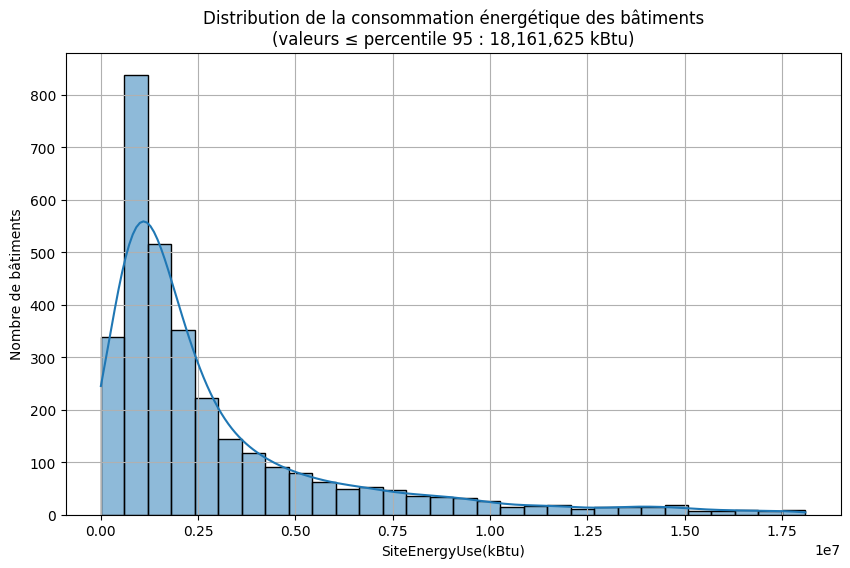

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variable cible
target = "SiteEnergyUse(kBtu)"

# Seuil d'affichage
seuil = df[target].quantile(0.95)

# Données filtrées uniquement pour le graphique
df_hist = df[df[target] <= seuil].copy()

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_hist,
    x=target,
    bins=30,
    kde=True
)

plt.title(f"Distribution de la consommation énergétique des bâtiments\n(valeurs ≤ percentile 95 : {seuil:,.0f} kBtu)")
plt.xlabel("SiteEnergyUse(kBtu)")
plt.ylabel("Nombre de bâtiments")
plt.grid(True)

plt.show()

In [216]:
seuil_99 = df_model[target].quantile(0.99)

df_target_filtre = df_model[
    df_model[target] <= seuil_99
].copy()

print("Seuil du 99e percentile :", seuil_99)
print("Nombre de lignes avant filtrage :", df_model.shape[0])
print("Nombre de lignes après filtrage visuel :", df_target_filtre.shape[0])

Seuil du 99e percentile : 53948614.800000295
Nombre de lignes avant filtrage : 3371
Nombre de lignes après filtrage visuel : 3337


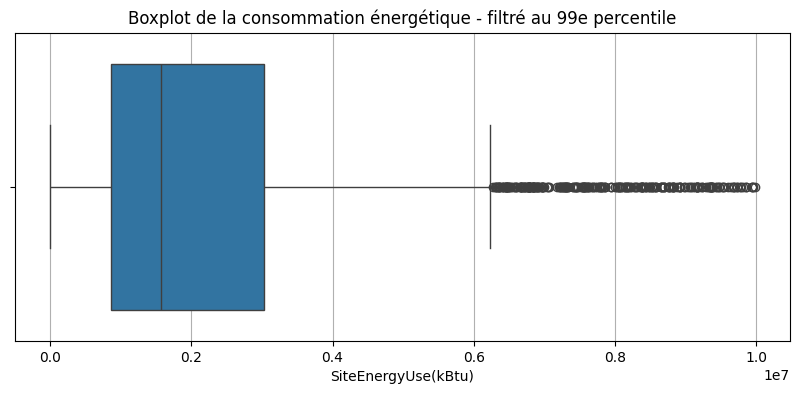

In [217]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data = df_target_filtre[df_target_filtre['SiteEnergyUse(kBtu)'] <= 10000000],
    x=target
)

plt.title("Boxplot de la consommation énergétique - filtré au 99e percentile")
plt.xlabel("SiteEnergyUse(kBtu)")
plt.grid(True, axis="x")
plt.show()

In [218]:
target = "SiteEnergyUse(kBtu)"

# Seuil du 97e percentile
seuil_97 = df_model[target].quantile(0.97)

print("Seuil du 97e percentile :", seuil_97)
print("Seuil en millions de kBtu :", seuil_97 / 1_000_000)

# Outliers = les 3 % les plus élevés
outliers_target = df_model[df_model[target] > seuil_97].copy()

print("Nombre d'outliers :", outliers_target.shape[0])
print("Pourcentage d'outliers :", round(outliers_target.shape[0] / df_model.shape[0] * 100, 2), "%")

Seuil du 97e percentile : 26372117.80000004
Seuil en millions de kBtu : 26.37211780000004
Nombre d'outliers : 102
Pourcentage d'outliers : 3.03 %


In [219]:
df_model_clean = df_model[df_model[target] <= seuil_97].copy()

print("Nombre de lignes avant :", df_model.shape[0])
print("Nombre de lignes après :", df_model_clean.shape[0])
print("Nombre de lignes supprimées :", df_model.shape[0] - df_model_clean.shape[0])
print("Pourcentage supprimé :", round((df_model.shape[0] - df_model_clean.shape[0]) / df_model.shape[0] * 100, 2), "%")

Nombre de lignes avant : 3371
Nombre de lignes après : 3269
Nombre de lignes supprimées : 102
Pourcentage supprimé : 3.03 %


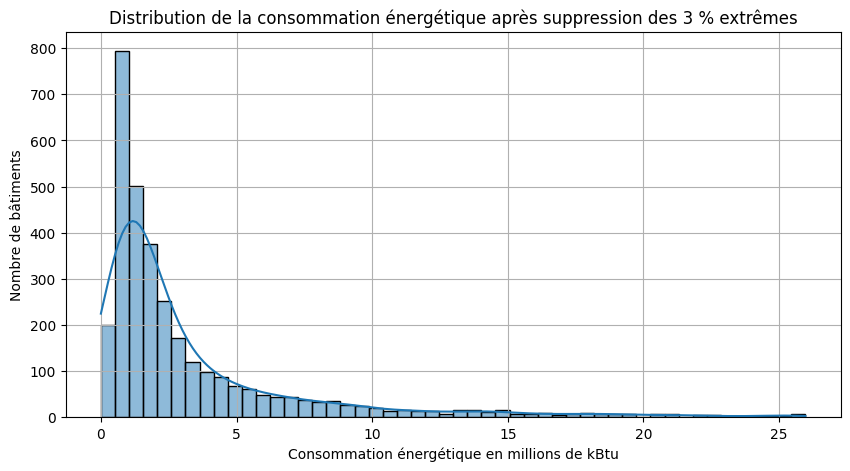

In [220]:
df_model_clean["SiteEnergyUse_MkBtu"] = df_model_clean[target] / 1_000_000

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_model_clean,
    x="SiteEnergyUse_MkBtu",
    bins=50,
    kde=True
)

plt.title("Distribution de la consommation énergétique après suppression des 3 % extrêmes")
plt.xlabel("Consommation énergétique en millions de kBtu")
plt.ylabel("Nombre de bâtiments")
plt.grid(True)
plt.show()

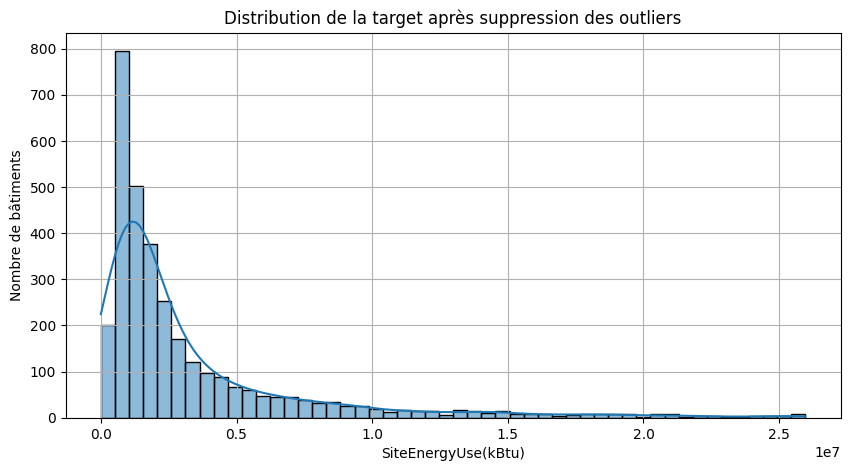

In [221]:
plt.figure(figsize=(10, 5))

sns.histplot(df_model_clean[target], bins=50, kde=True)

plt.title("Distribution de la target après suppression des outliers")
plt.xlabel("SiteEnergyUse(kBtu)")
plt.ylabel("Nombre de bâtiments")
plt.grid(True)
plt.show()

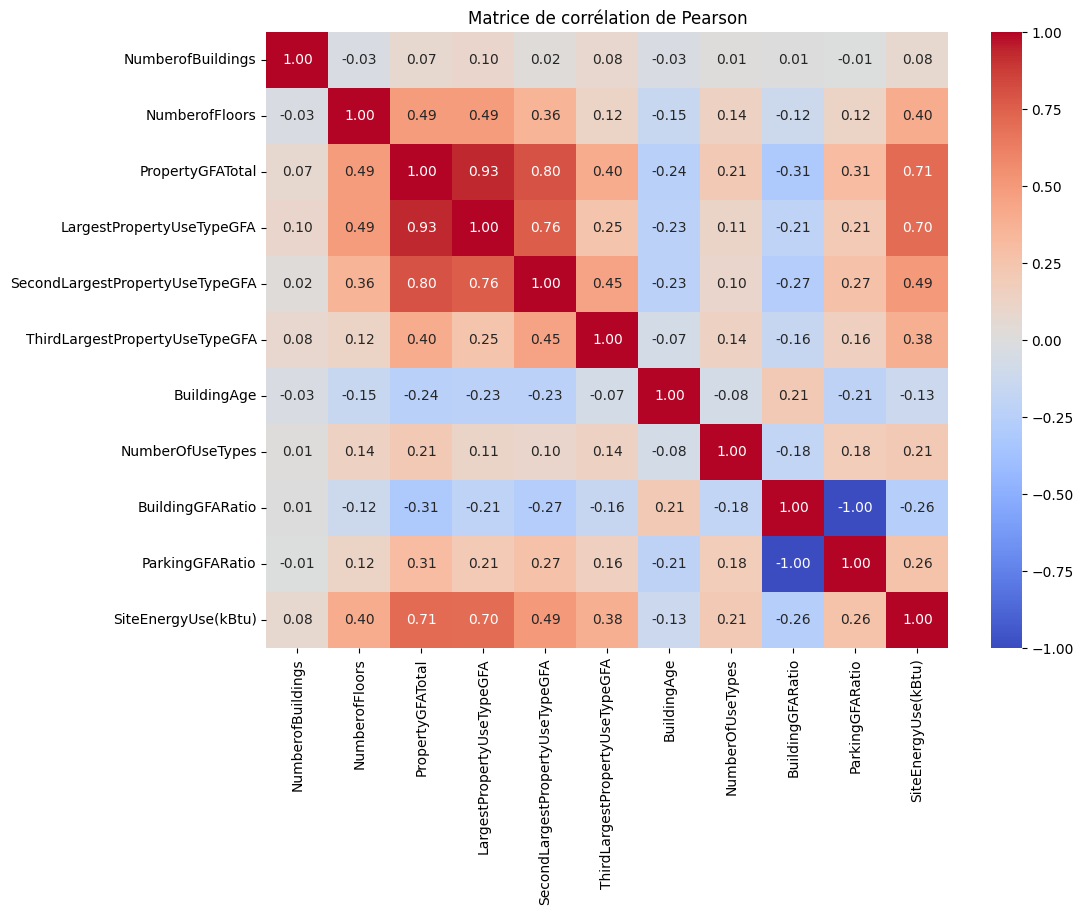

In [222]:
df_numeric = df_model_clean[features_numeriques + [target]]

corr_matrix = df_numeric.corr(method="pearson")

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation de Pearson")
plt.show()

In [223]:
corr_features = df_model_clean[features_numeriques].corr(method="pearson").abs()

upper_triangle = corr_features.where(
    np.triu(np.ones(corr_features.shape), k=1).astype(bool)
)

seuil_correlation = 0.85

features_redondantes = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > seuil_correlation)
]

features_redondantes

['LargestPropertyUseTypeGFA', 'ParkingGFARatio']

In [224]:
features_a_supprimer_correlation = []

# Exemple : à activer uniquement si la corrélation est trop forte dans ton résultat
# features_a_supprimer_correlation = ["LargestPropertyUseTypeGFA"]

df_model_clean = df_model_clean.drop(
    columns=[col for col in features_a_supprimer_correlation if col in df_model_clean.columns]
)

features_numeriques = [
    col for col in features_numeriques
    if col not in features_a_supprimer_correlation
]

features = features_numeriques + features_categorielles

print("Features finales :", features)
print("Nombre de features finales :", len(features))

Features finales : ['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'BuildingAge', 'NumberOfUseTypes', 'BuildingGFARatio', 'ParkingGFARatio', 'BuildingType', 'PrimaryPropertyType', 'LargestPropertyUseType', 'BuildingAgeCategory', 'usage_type']
Nombre de features finales : 15


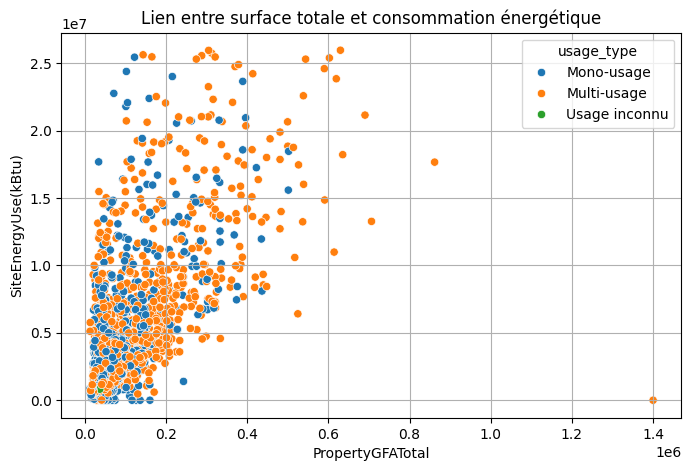

In [225]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_model_clean,
    x="PropertyGFATotal",
    y=target,
    hue="usage_type"
)

plt.title("Lien entre surface totale et consommation énergétique")
plt.xlabel("PropertyGFATotal")
plt.ylabel("SiteEnergyUse(kBtu)")
plt.grid(True)
plt.show()

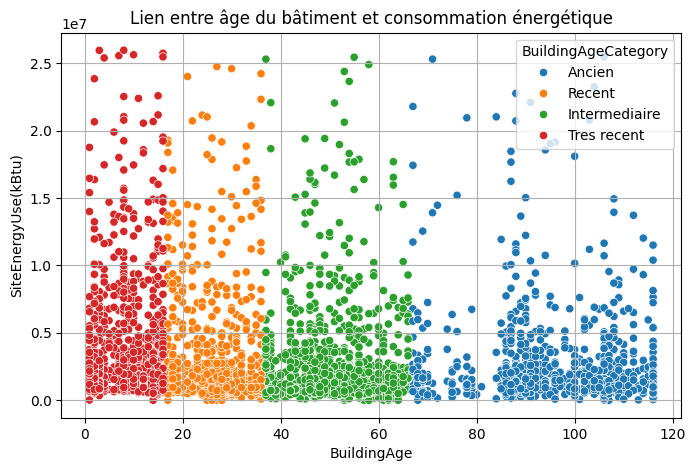

In [226]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_model_clean,
    x="BuildingAge",
    y=target,
    hue="BuildingAgeCategory"
)

plt.title("Lien entre âge du bâtiment et consommation énergétique")
plt.xlabel("BuildingAge")
plt.ylabel("SiteEnergyUse(kBtu)")
plt.grid(True)
plt.show()

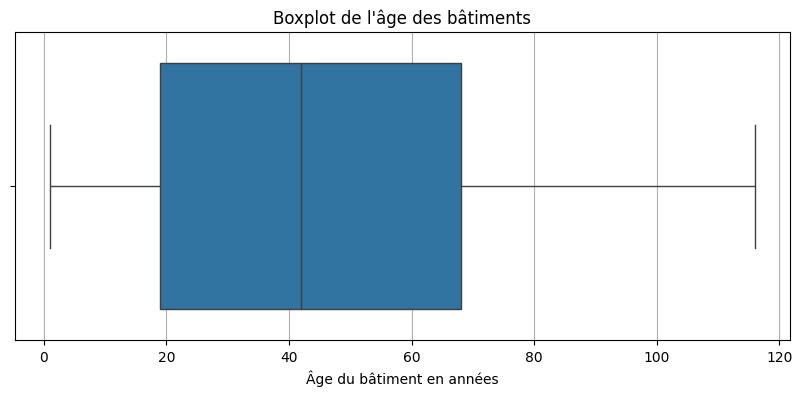

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df_model_clean,
    x="BuildingAge"
)

plt.title("Boxplot de l'âge des bâtiments")
plt.xlabel("Âge du bâtiment en années")
plt.grid(True, axis="x")

plt.show()

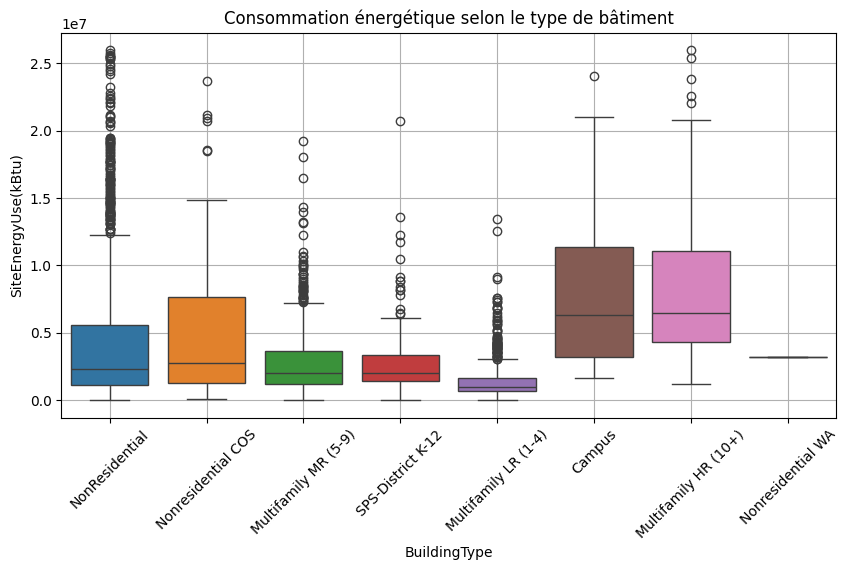

In [228]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_model_clean,
    x="BuildingType",
    y=target,
    hue="BuildingType",
    legend=False
)

plt.title("Consommation énergétique selon le type de bâtiment")
plt.xlabel("BuildingType")
plt.ylabel("SiteEnergyUse(kBtu)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

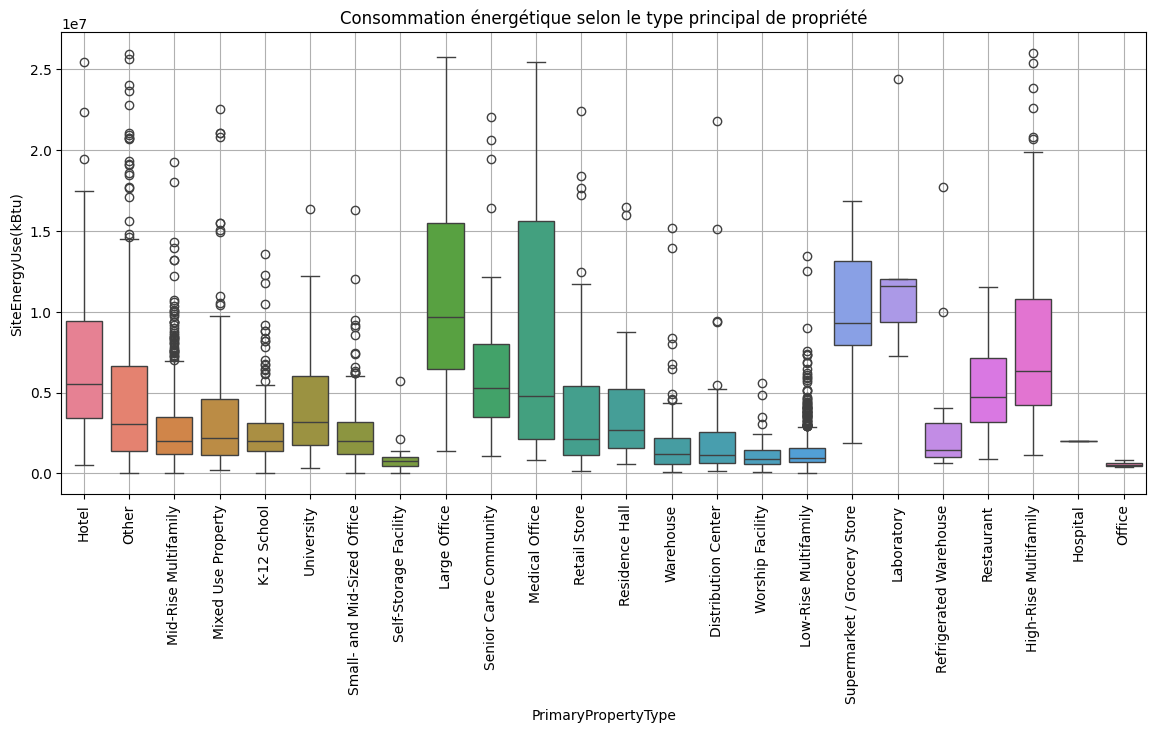

In [229]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_model_clean,
    x="PrimaryPropertyType",
    y=target,
    hue="PrimaryPropertyType",
    legend=False
)

plt.title("Consommation énergétique selon le type principal de propriété")
plt.xlabel("PrimaryPropertyType")
plt.ylabel("SiteEnergyUse(kBtu)")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

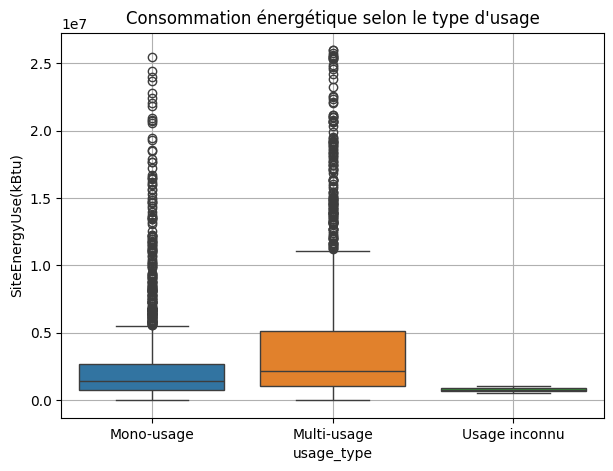

In [230]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_model_clean,
    x="usage_type",
    y=target,
    hue="usage_type",
    legend=False
)

plt.title("Consommation énergétique selon le type d'usage")
plt.xlabel("usage_type")
plt.ylabel("SiteEnergyUse(kBtu)")
plt.grid(True)
plt.show()

In [231]:
X = df_model_clean[features].copy()
y = df_model_clean[target].copy()

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (3269, 15)
Dimensions de y : (3269,)


In [232]:
X.dtypes

NumberofBuildings                  float64
NumberofFloors                       int64
PropertyGFATotal                     int64
LargestPropertyUseTypeGFA          float64
SecondLargestPropertyUseTypeGFA    float64
ThirdLargestPropertyUseTypeGFA     float64
BuildingAge                          int64
NumberOfUseTypes                     int64
BuildingGFARatio                   float64
ParkingGFARatio                    float64
BuildingType                           str
PrimaryPropertyType                    str
LargestPropertyUseType                 str
BuildingAgeCategory                    str
usage_type                             str
dtype: object

In [233]:
features_numeriques = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
features_categorielles = X.select_dtypes(include=["object"]).columns.tolist()

print("Features numériques :", features_numeriques)
print("Nombre de features numériques :", len(features_numeriques))

print("\nFeatures catégorielles :", features_categorielles)
print("Nombre de features catégorielles :", len(features_categorielles))

Features numériques : ['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'BuildingAge', 'NumberOfUseTypes', 'BuildingGFARatio', 'ParkingGFARatio']
Nombre de features numériques : 10

Features catégorielles : ['BuildingType', 'PrimaryPropertyType', 'LargestPropertyUseType', 'BuildingAgeCategory', 'usage_type']
Nombre de features catégorielles : 5


C:\Users\johnd\AppData\Local\Temp\ipykernel_34152\2035404536.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  features_categorielles = X.select_dtypes(include=["object"]).columns.tolist()


In [234]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            features_numeriques
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
            ]),
            features_categorielles
        )
    ]
)

In [235]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (2615, 15)
X_test : (654, 15)
y_train : (2615,)
y_test : (654,)


In [236]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² : 0.7204703990879578
MAE : 1371655.3866497406
RMSE : 2312160.8534315033


i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [237]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

scores_r2 = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

scores_mae = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

scores_rmse = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

print("R² moyen :", scores_r2.mean())
print("Écart-type R² :", scores_r2.std())

print("MAE moyenne :", -scores_mae.mean())
print("Écart-type MAE :", scores_mae.std())

print("RMSE moyenne :", -scores_rmse.mean())
print("Écart-type RMSE :", scores_rmse.std())

i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
i:\OC\P3\projet3\.venv\Lib\site-packa

R² moyen : 0.6516587915650971
Écart-type R² : 0.06744248403288684
MAE moyenne : 1337834.751045306
Écart-type MAE : 89301.13163192933
RMSE moyenne : 2474940.3731735735
Écart-type RMSE : 232927.25047681644


i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [238]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

alphas = [0.01, 0.1, 1, 10, 100, 1000]

resultats_ridge = []

for alpha in alphas:
    
    ridge_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=alpha))
    ])
    
    scores_r2 = cross_val_score(
        ridge_model,
        X,
        y,
        cv=kf,
        scoring="r2"
    )
    
    scores_mae = cross_val_score(
        ridge_model,
        X,
        y,
        cv=kf,
        scoring="neg_mean_absolute_error"
    )
    
    scores_rmse = cross_val_score(
        ridge_model,
        X,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )
    
    resultats_ridge.append({
        "alpha": alpha,
        "R2_moyen": scores_r2.mean(),
        "R2_ecart_type": scores_r2.std(),
        "MAE_moyenne": -scores_mae.mean(),
        "MAE_ecart_type": scores_mae.std(),
        "RMSE_moyenne": -scores_rmse.mean(),
        "RMSE_ecart_type": scores_rmse.std()
    })

resultats_ridge = pd.DataFrame(resultats_ridge)

resultats_ridge.sort_values("R2_moyen", ascending=False)

i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
i:\OC\P3\projet3\.venv\Lib\site-packa

,alpha,R2_moyen,R2_ecart_type,MAE_moyenne,MAE_ecart_type,RMSE_moyenne,RMSE_ecart_type
2,1.00,0.655488,0.075600,1.329885e+06,78209.257397,2.456901e+06,235986.482264
3,10.00,0.652351,0.072911,1.342038e+06,62529.294085,2.468402e+06,217135.823167
1,0.10,0.650902,0.076373,1.332888e+06,88739.237378,2.473879e+06,247272.855661
0,0.01,0.650760,0.069425,1.337112e+06,89213.799175,2.477373e+06,236518.370629
4,100.00,0.627597,0.082738,1.404204e+06,56307.661745,2.551898e+06,229325.791006
5,1000.00,0.561836,0.084001,1.565339e+06,54389.368872,2.773705e+06,230218.860171


In [239]:
meilleur_resultat = resultats_ridge.sort_values(
    "R2_moyen",
    ascending=False
).iloc[0]

meilleur_alpha = meilleur_resultat["alpha"]

print("Meilleur alpha :", meilleur_alpha)
print(meilleur_resultat)

Meilleur alpha : 1.0
alpha              1.000000e+00
R2_moyen           6.554880e-01
R2_ecart_type      7.559968e-02
MAE_moyenne        1.329885e+06
MAE_ecart_type     7.820926e+04
RMSE_moyenne       2.456901e+06
RMSE_ecart_type    2.359865e+05
Name: 2, dtype: float64


In [240]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

ridge_final = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=meilleur_alpha))
])

ridge_final.fit(X_train, y_train)

y_pred_ridge = ridge_final.predict(X_test)

print("R² Ridge final :", r2_score(y_test, y_pred_ridge))
print("MAE Ridge final :", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE Ridge final :", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

R² Ridge final : 0.7249722882491654
MAE Ridge final : 1360127.0192477012
RMSE Ridge final : 2293466.33416709


i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### Comparaison de différents modèles supervisés

In [241]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [242]:
target = "SiteEnergyUse(kBtu)"

features_numeriques = [
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFATotal",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
    "BuildingAge",
    "NumberOfUseTypes",
    "BuildingGFARatio",
    "ParkingGFARatio"
]

features_categorielles = [
    "BuildingType",
    "PrimaryPropertyType",
    "LargestPropertyUseType",
    "BuildingAgeCategory",
    "usage_type"
]

features = features_numeriques + features_categorielles

X = df_model_clean[features].copy()
y = df_model_clean[target].copy()

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (3269, 15)
Dimensions de y : (3269,)


In [243]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            features_numeriques
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            features_categorielles
        )
    ]
)

In [244]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (2615, 15)
X_test : (654, 15)
y_train : (2615,)
y_test : (654,)


In [245]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [246]:
y_pred_rf = rf_model.predict(X_test)

print("R² Random Forest :", r2_score(y_test, y_pred_rf))
print("MAE Random Forest :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE Random Forest :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R² Random Forest : 0.7265294145254451
MAE Random Forest : 1252490.0563311137
RMSE Random Forest : 2286964.651435482


In [247]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_r2_rf = cross_val_score(
    rf_model,
    X,
    y,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

scores_mae_rf = cross_val_score(
    rf_model,
    X,
    y,
    cv=kf,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

scores_rmse_rf = cross_val_score(
    rf_model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("R² moyen Random Forest :", scores_r2_rf.mean())
print("Écart-type R² Random Forest :", scores_r2_rf.std())

print("MAE moyenne Random Forest :", -scores_mae_rf.mean())
print("Écart-type MAE Random Forest :", scores_mae_rf.std())

print("RMSE moyenne Random Forest :", -scores_rmse_rf.mean())
print("Écart-type RMSE Random Forest :", scores_rmse_rf.std())

R² moyen Random Forest : 0.6885293198345174
Écart-type R² Random Forest : 0.040227092053830814
MAE moyenne Random Forest : 1234268.7588922097
Écart-type MAE Random Forest : 61703.80726147665
RMSE moyenne Random Forest : 2345368.175004093
Écart-type RMSE Random Forest : 141337.604771431


In [249]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("regressor", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "regressor__n_estimators": [100, 300],
    "regressor__max_depth": [10, 20],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2]
}

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_search_rf.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search_rf.best_params_)
print("Meilleur R² moyen en validation croisée :", grid_search_rf.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Meilleurs paramètres : {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 300}
Meilleur R² moyen en validation croisée : 0.6739517448597117


In [250]:
rf_model.fit(X_train, y_train)

preprocessor_fitted = rf_model.named_steps["preprocessor"]
regressor_fitted = rf_model.named_steps["regressor"]

feature_names_num = features_numeriques

feature_names_cat = (
    preprocessor_fitted
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(features_categorielles)
)

feature_names_all = list(feature_names_num) + list(feature_names_cat)

importances = regressor_fitted.feature_importances_

feature_importances = pd.DataFrame({
    "feature": feature_names_all,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importances.head(20)

,feature,importance
2,PropertyGFATotal,0.450496
3,LargestPropertyUseTypeGFA,0.199530
6,BuildingAge,0.041213
1,NumberofFloors,0.039569
38,PrimaryPropertyType_Supermarket / Grocery Store,0.033799
4,SecondLargestPropertyUseTypeGFA,0.022280
14,BuildingType_NonResidential,0.018691
61,LargestPropertyUseType_Multifamily Housing,0.017917
5,ThirdLargestPropertyUseTypeGFA,0.017205
71,LargestPropertyUseType_Other - Recreation,0.008223


A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [ ]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE